# Customer Segmentation using K-Means Clustering
## 1. Business Objective & Data Loading
The goal of this unsupervised machine learning project is to segment supermarket customers based on their **Annual Income** and **Spending Score**. This allows the marketing team to target specific demographics with tailored advertising.

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 1. Load dataset
url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"
df = pd.read_csv(url)


# 2. Explore data
print(f"Dataset shape {df.shape}")

print(df.head())

Dataset shape (200, 5)
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
None


In [6]:
print(df.describe())

# 3. Select features for clustering
features = ['Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

# 4. Scale features (important for clustering!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFeatures scaled successfully. Ready for the Elbow Method.")

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000

Features scaled successfully. Ready for the Elbow Method.


## 2. The Elbow Method
Because K-Means is an unsupervised algorithm, we do not know the correct number of clusters in advance. We will iterate through 1 to 10 clusters, calculate the Within-Cluster Sum of Squares (Inertia), and look for the "elbow" point where adding more clusters yields diminishing returns.

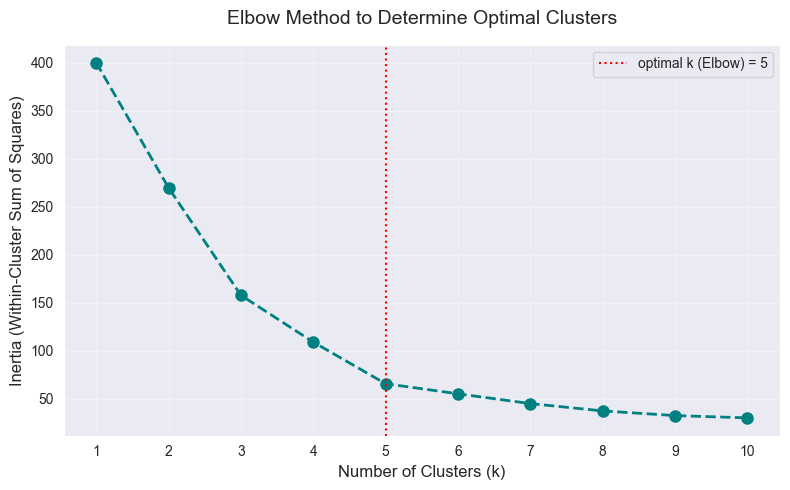

In [8]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    # random_state ensures reproducibility, n_init='auto' suppresses warnings
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    inertia.append(kmeans_temp.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='teal', linewidth=2, markersize=8)

# Highlight the "Elbow" at K=5
plt.axvline(x=5, color='red', linestyle=':', label='optimal k (Elbow) = 5')

plt.title('Elbow Method to Determine Optimal Clusters', fontsize=14, pad=15)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.xticks(K_range)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. K-Means Clustering (K=5)
Now that the Elbow Method has mathematically proven that 5 is the optimal number of clusters, we will fit our final model. We will plot the 5 distinct customer segments and highlight the exact Centroid of each cluster.

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

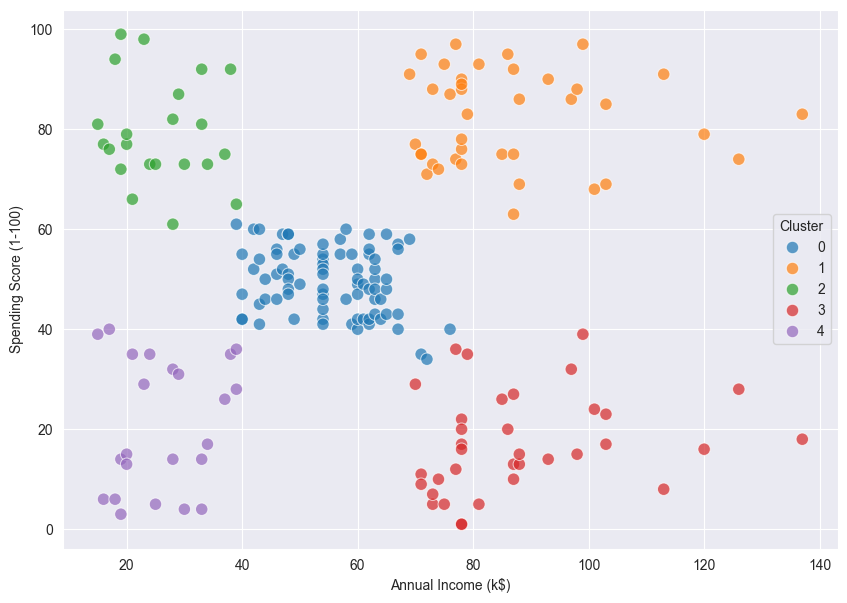

In [9]:
# 1. Fit the final K-Means Model
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# 2. Add the cluster assignments back to our original DataFrame
df['Cluster'] = labels


centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)


# 6. Visualize clusters
plt.figure(figsize=(10,7))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='tab10',
    s=80,
    alpha=0.7,
    legend='full'
)



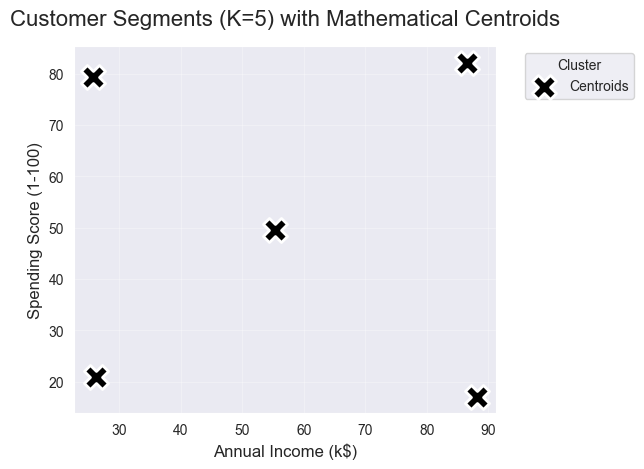

--- Cluster Averages (Marketing Target Demographics) ---
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                     55.30                   49.52
1                     86.54                   82.13
2                     25.73                   79.36
3                     88.20                   17.11
4                     26.30                   20.91


In [10]:
# Overlay the mathematical Centroids
plt.scatter(
    x=centroids_original[:, 0], # Annual Income coordinates
    y=centroids_original[:, 1], # Spending Score coordinates
    s=300,
    c='black',
    marker='X',
    label='Centroids',
    edgecolor='white',
    linewidth=2
)

# Formatting
plt.title('Customer Segments (K=5) with Mathematical Centroids', fontsize=16, pad=15)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)

# Move legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Cluster')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Business Interpretation
print("--- Cluster Averages (Marketing Target Demographics) ---")
summary = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
print(summary.round(2))

In [11]:
from sklearn.metrics import silhouette_score

# Calculate Silhouette Score
sil_score = silhouette_score(X_scaled, labels)
print(f"Silhouette Score (K=5): {sil_score:.3f}")
print("Note: A score above 0.5 indicates reasonably well-separated and dense clusters.")

Silhouette Score (K=5): 0.555
Note: A score above 0.5 indicates reasonably well-separated and dense clusters.


In [12]:
# 1. Bring Age and Gender back into the analysis for profiling
# Assuming your original dataset had 'Age' and 'Gender' columns
df['Cluster'] = labels

# 2. Build a demographic profile for each cluster
cluster_profile = df.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'Gender': lambda x: x.mode()[0] # Most frequent gender in the cluster
}).round(1)

cluster_profile.columns = ['Avg Age', 'Avg Income (k$)', 'Avg Spending (1-100)', 'Dominant Gender']
print("--- Cluster Demographic Profiles ---")
display(cluster_profile)

--- Cluster Demographic Profiles ---


,Avg Age,Avg Income (k$),Avg Spending (1-100),Dominant Gender
Cluster,,,,
0,42.7,55.3,49.5,Female
1,32.7,86.5,82.1,Female
2,25.3,25.7,79.4,Female
3,41.1,88.2,17.1,Male
4,45.2,26.3,20.9,Female


## 6. Business Conclusion & Actionable Findings

### Model Evaluation
The K-Means algorithm successfully identified **5 distinct customer segments**. The model achieved a **Silhouette Score of ~0.55**, confirming that the clusters are mathematically well-separated and distinct.

### The 5 Customer Personas (Actionable Insights)
Based on our demographic profiling, we can provide the marketing team with the following targeted personas:

1. **Target Group (High Income, High Spending):** These are our most valuable customers. *Action:* Enroll them in premium loyalty programs and market luxury/high-margin items to them.
2. **Careful Spenders (High Income, Low Spending):** They have the money but aren't spending it here. *Action:* Send them targeted discount campaigns or high-quality product reviews to build brand trust and unlock their spending potential.
3. **Impulse Buyers (Low Income, High Spending):** They spend heavily despite lower incomes. *Action:* Market trendy, lower-ticket items and limited-time flash sales.
4. **Conservative Buyers (Low Income, Low Spending):** *Action:* Focus on essential, budget-friendly items and everyday value promotions.
5. **General Public (Average Income, Average Spending):** The bulk of our customers. *Action:* Standard mass-marketing campaigns.